# Import Necessary libraries:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Load and read dataset:

In [2]:
df = pd.read_csv("ecommerce_sales_data.csv")

# Data Explanation:

In [3]:
df.head()

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2024-12-31,Printer,Office,North,4,3640,348.93
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73
3,2024-03-16,Mouse,Accessories,South,2,786,202.87
4,2022-09-10,Mouse,Accessories,West,1,509,103.28


# Check basic info about dataset:

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    3500 non-null   object 
 1   Product Name  3500 non-null   object 
 2   Category      3500 non-null   object 
 3   Region        3500 non-null   object 
 4   Quantity      3500 non-null   int64  
 5   Sales         3500 non-null   int64  
 6   Profit        3500 non-null   float64
dtypes: float64(1), int64(2), object(4)
memory usage: 191.5+ KB


# Handle missing values:

In [5]:
df.isnull().sum()

Order Date      0
Product Name    0
Category        0
Region          0
Quantity        0
Sales           0
Profit          0
dtype: int64

# Check duplicate rows:

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df = df.drop_duplicates()

# Convert Order Date to datetime:

In [8]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Add month and year columns:

In [9]:
df['Month'] = df['Order Date'].dt.month

In [10]:
df['Year'] = df['Order Date'].dt.year

# Clean data preview:

In [11]:
df.head()

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit,Month,Year
0,2024-12-31,Printer,Office,North,4,3640,348.93,12,2024
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53,11,2022
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73,5,2022
3,2024-03-16,Mouse,Accessories,South,2,786,202.87,3,2024
4,2022-09-10,Mouse,Accessories,West,1,509,103.28,9,2022


# Monthly Sales Trend Analysis:

In [12]:
monthly_sales = df.groupby('Month')['Sales'].sum()
monthly_sales

Month
1      967614
2      702414
3      939614
4      821876
5     1034687
6      839805
7      844940
8      924939
9      885546
10     892269
11     855075
12     959102
Name: Sales, dtype: int64

# Line Chart:

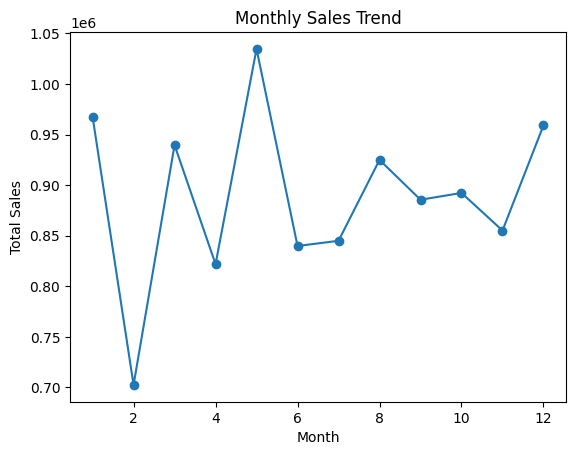

In [13]:
plt.figure()
monthly_sales.plot(kind='line', marker='o')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.title('Monthly Sales Trend')
plt.show()

# Find Highest and Lowest sales:

In [14]:
highest_month = monthly_sales.idxmax()

In [15]:
lowest_month = monthly_sales.idxmin()

In [16]:
highest_month, lowest_month

(np.int32(5), np.int32(2))

# Explanation:

It explains that sales change over time and highlights the importance of using marketing strategies to improve low-performing months.

# Top Five best Selling Products:

*  # Calculate product wise total sales:

In [17]:
product_sales = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False)
product_sales.head()

Product Name
Camera        1177381
Monitor       1160048
Printer       1094216
Mouse         1074398
Smartphone    1069681
Name: Sales, dtype: int64

# Select top 5 products:

In [18]:
top_5_products = product_sales.head(5)
top_5_products

Product Name
Camera        1177381
Monitor       1160048
Printer       1094216
Mouse         1074398
Smartphone    1069681
Name: Sales, dtype: int64

# Bar Chart:

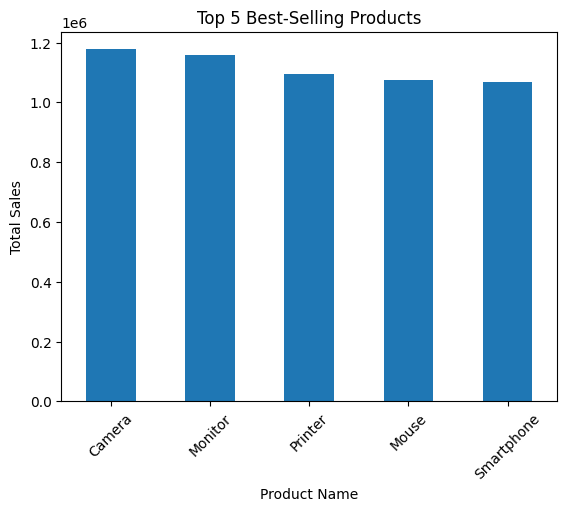

In [19]:
plt.figure()
top_5_products.plot(kind='bar')
plt.xlabel('Product Name')
plt.ylabel('Total Sales')
plt.title('Top 5 Best-Selling Products')
plt.xticks(rotation=45)
plt.show()

# Written insights:

The analysis identifies the top five best-selling products based on total sales. These products perform well due to high customer demand, strong brand preference, or effective marketing strategies. The business can focus on maintaining stock availability and promoting these products further to maximize revenue.

# Region-wise Sales Performance:

*  # To Calculate region wise total sales:

In [20]:
region_sales = df.groupby('Region')['Sales'].sum()
region_sales

Region
East     2675110
North    2488773
South    2659548
West     2844450
Name: Sales, dtype: int64

# Bar chart ( region wise):

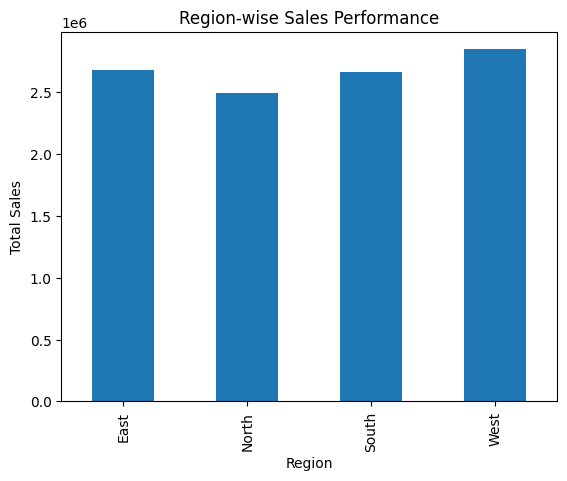

In [21]:
plt.figure()
region_sales.plot(kind='bar')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.title('Region-wise Sales Performance')
plt.show()

# Insight:

This chart illustrates which regions are performing well in terms of sales and which regions have lower sales performance.

# To find best and lowst performing region:

In [22]:
best_region = region_sales.idxmax()

In [23]:
lowest_region = region_sales.idxmin()

In [24]:
best_region, lowest_region

('West', 'North')

# Written Insights:

The region-wise sales analysis shows that some regions perform better than others. The best-performing region may benefit from higher customer demand or better market presence, while the lowest-performing region indicates an opportunity to improve sales through targeted marketing and regional strategies.

# Profit Analysis:

*  # Calculate product wise sales and profit:

In [25]:
profit_analysis = df.groupby('Product Name')[['Sales', 'Profit']].sum()
profit_analysis.head()

,Sales,Profit
Product Name,,
Camera,1177381,207630.99
Headphones,988638,172478.20
Keyboard,1024507,175814.68
Laptop,1005873,185756.81
Monitor,1160048,202028.17


# Identify High sales but low profit products:

In [26]:
high_sales_low_profit = profit_analysis.sort_values(by='Sales', ascending=False).head(10)
high_sales_low_profit

,Sales,Profit
Product Name,,
Camera,1177381,207630.99
Monitor,1160048,202028.17
Printer,1094216,185394.88
Mouse,1074398,185763.69
Smartphone,1069681,183296.97
Smartwatch,1049211,178995.81
Keyboard,1024507,175814.68
Tablet,1023928,167505.01
Laptop,1005873,185756.81


# Simple Comparrison bar chart:

<Figure size 640x480 with 0 Axes>

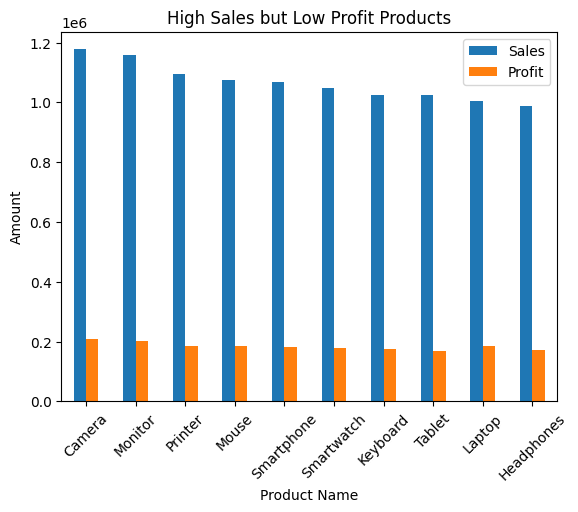

In [27]:
plt.figure()
high_sales_low_profit[['Sales', 'Profit']].plot(kind='bar')
plt.xlabel('Product Name')
plt.ylabel('Amount')
plt.title('High Sales but Low Profit Products')
plt.xticks(rotation=45)
plt.show()

This chart show the comparison of top selling products

# Written insights:

This analysis highlights products that generate high sales but relatively low profit. This may indicate high costs, heavy discounts, or pricing issues. The business should review pricing strategies and cost structures for these products to improve overall profitability.

# Final Conclusion:

This project analyzed e-commerce sales data to understand sales trends, product performance, regional sales distribution, and profitability. The analysis revealed clear monthly sales variations, identified top-performing products, highlighted the best and lowest-performing regions, and uncovered products with high sales but low profit. These insights can help management make data-driven decisions related to marketing strategies, inventory planning, regional improvement, and pricing optimization to improve overall business performance.